Loading small matrix A...
Matrix A loaded! Size: 961 x 961
Manufacturing vector b...
Vector b generated! Shape: (961,)
Running GMRES (max iterations: 50)...


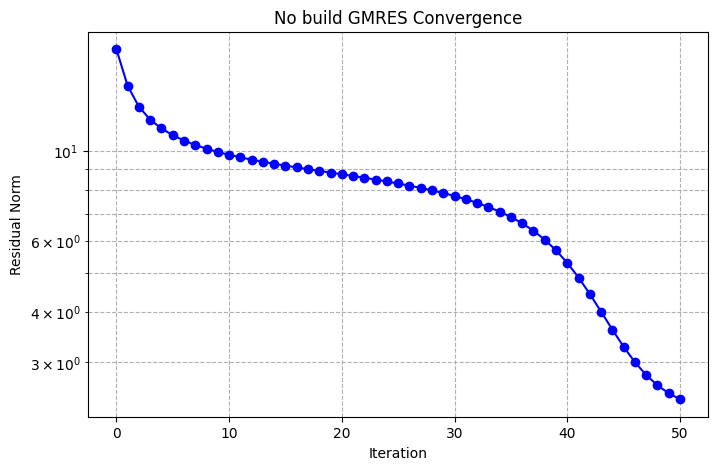

Converged in 50 iterations.
Final residual norm: 2.433582994904544


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import mmread

def gmres_no_build(A, b, x0=None, max_iter=100, tol=1e-8):
    """
    GMRES algorithm solving Ax = b using progressive Givens rotations.
    This avoids solving the least squares problem at every step.
    
    Parameters:
    A        : ndarray, the coefficient matrix (n x n)
    b        : ndarray, the right-hand side vector (n,)
    x0       : ndarray, initial guess (default is zero vector)
    max_iter : int, maximum number of iterations
    tol      : float, tolerance for the residual norm
    
    Returns:
    x        : ndarray, the estimated solution
    res_hist : list, history of the residual norms
    """
    # Get the size of the matrix A
    n = A.shape[0]
    
    # If no initial guess is provided, start with a vector of zeros
    if x0 is None:
        x0 = np.zeros(n)
        
    # # Initial residual
    A_times_x0 = A.dot(x0)
    r0 = b - A_times_x0
    
    # Calculate the norm (length) of the initial residual
    beta = np.linalg.norm(r0)
    
    # Keep track of the residual norms for plotting later
    res_hist = [beta]
    
    # If the initial guess is already good enough
    if beta < tol:
        return x0, res_hist
    
    # Set up empty matrices to hold calculations
    # V holds the basis vectors
    V = np.zeros((n, max_iter + 1))
    # H holds the Hessenberg matrix values
    H = np.zeros((max_iter + 1, max_iter))
    
    # The first column of V is the normalized initial residual
    V[:, 0] = r0 / beta
    
    # Store the cosines and sines for each rotation
    cs = np.zeros(max_iter) 
    sn = np.zeros(max_iter)
    
    # g is the right-hand side vector for the triangular system (initially beta * e1)
    g = np.zeros(max_iter + 1)
    g[0] = beta
    
    iterations_run = 0
    
    for m in range(max_iter):
        iterations_run = m + 1
        
        # Arnoldi Iteration
        v_next = A.dot(V[:, m])
        
        for j in range(m + 1):
            H[j, m] = np.dot(V[:, j], v_next)
            v_next = v_next - (H[j, m] * V[:, j])
            
        H[m + 1, m] = np.linalg.norm(v_next)
        
        if H[m + 1, m] != 0:
            V[:, m + 1] = v_next / H[m + 1, m]
            
        # Apply all previous rotations to the new column of H
        for i in range(m):
            temp        =  (cs[i] * H[i, m]) + (sn[i] * H[i + 1, m])
            H[i + 1, m] = -(sn[i] * H[i, m]) + (cs[i] * H[i + 1, m])
            H[i, m]     = temp
            
        # Calculate the new rotation to zero out H[m+1, m]
        # r is the hypotenuse: sqrt(a^2 + b^2)
        r = np.sqrt(H[m, m]**2 + H[m + 1, m]**2)
        
        # Calculate cosine and sine
        cs[m] = H[m, m] / r
        sn[m] = H[m + 1, m] / r
        
        # Apply the new rotation to H
        H[m, m] = r
        H[m + 1, m] = 0.0
        
        # Apply the new rotation to right-hand side vector g
        g[m + 1] = -sn[m] * g[m]
        g[m]     =  cs[m] * g[m]
        
        # The residual norm is simply the absolute value of the new element in g!
        current_res = abs(g[m + 1])
        res_hist.append(current_res)
        
        if current_res < tol:
            break

    # Change for part 3 is all lines from here to return values are now outside the for loop.
    # These lines are the lines responsible for building the GMRES approximate solution.
    # Only want to build these at the end of the for loop.
    
    # Because of Givens rotations, H is now an upper triangular matrix R.
    # Take out the m x m upper triangular portion and the matching g vector.
    R = H[0 : iterations_run, 0 : iterations_run]
    g_final = g[0 : iterations_run]
    
    # Solve the upper triangular system R * y = g_final
    y = np.linalg.solve(R, g_final)
    
    # Calculate final answer
    V_filled = V[:, 0 : iterations_run]
    V_times_y = np.dot(V_filled, y)
    
    # Final solution
    x = x0 + V_times_y
    
    return x, res_hist
    
if __name__ == "__main__":
# 1. Load the Matrix Market file for the small matrix
    print("Loading small matrix A...")
    # Replace with the actual file path to your small matrix
    A_sparse = mmread('cdde6.mtx').tocsr()
    n = A_sparse.shape[0]
    print(f"Matrix A loaded! Size: {n} x {n}")
    
    # 2. Manufacture the right-hand side vector 'b'
    print("Manufacturing vector b...")
    # Create a vector of exactly n ones
    x_true = np.ones(n)
    
    # Use the sparse matrix's built-in dot product!
    b = A_sparse.dot(x_true) 
    print(f"Vector b generated! Shape: {b.shape}")
    
    # Cap max_iter to prevent laptop running out of memory
    max_iterations_allowed = min(n, 50) 
    print(f"Running GMRES (max iterations: {max_iterations_allowed})...")
    
    # Run function
    x, res_history = gmres_no_build(A_sparse, b, max_iter=max_iterations_allowed)
    
    # Plot convergence
    plt.figure(figsize=(8, 5))
    plt.semilogy(res_history, marker='o', linestyle='-', color='b')
    plt.title('No build GMRES Convergence')
    plt.xlabel('Iteration')
    plt.ylabel('Residual Norm')
    plt.grid(True, which="both", ls="--")
    plt.show()
    
    # Print results
    total_iterations = len(res_history) - 1
    final_residual = res_history[-1]
    
    print("Converged in", total_iterations, "iterations.")
    print("Final residual norm:", final_residual)
    